### Lab 2 - Energy Tracking Projectile

**Student:** Zaki Daouk  
**Date:** 2026-09-06

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Part A - Two-Dimensional Projectile with Energy Tracking

This section models a projectile launched from flat ground without air resistance, with energy tracking using $a_x = 0$ and $a_y = -g$. KE = ½ m (vx² + vy²)
PE = m g y    (measuring y upward from the launch height)
Etotal = KE + PE

Range:       90.633 m | exact: 90.349 m | error: 0.31%
Max height:  27.034 m | exact: 26.919 m | error: 0.43%
Flight time: 4.700 s | exact: 4.685 s | error: 0.31%


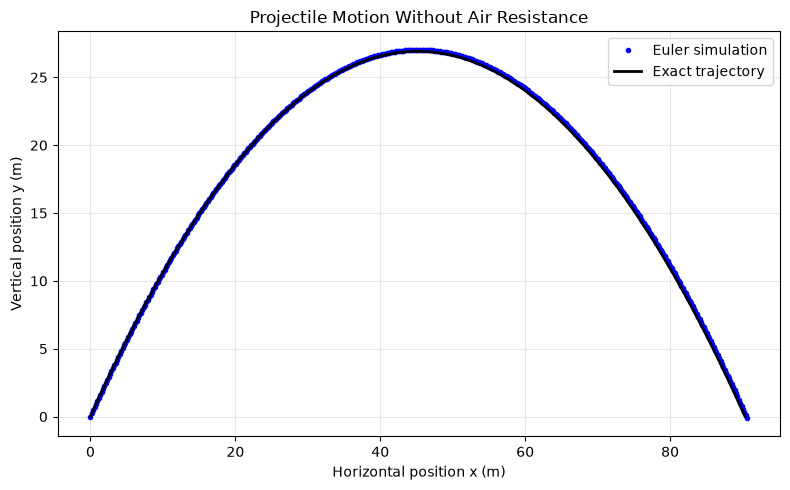

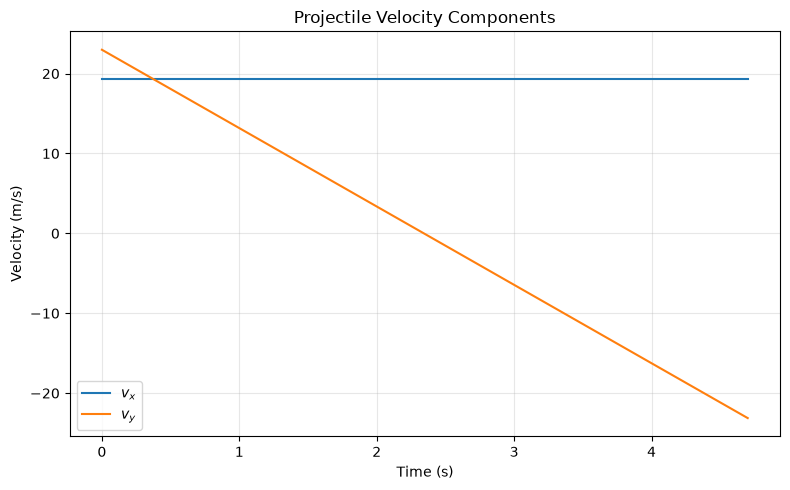

Maximum numerical range occurs at 45 degrees.


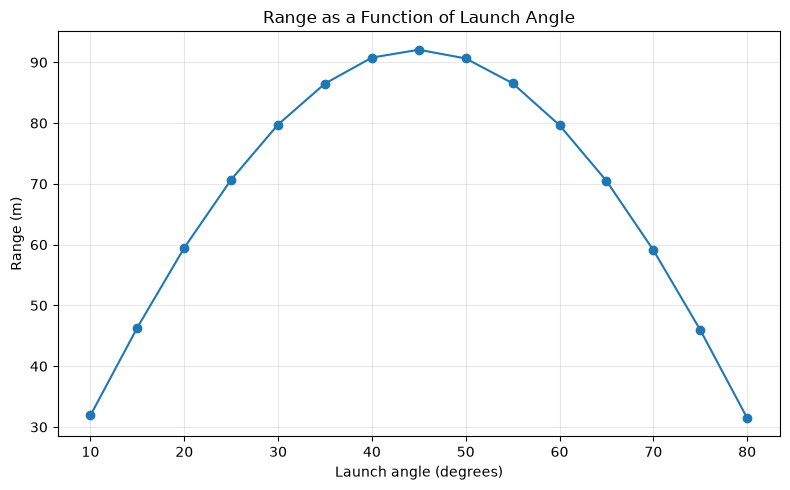

In [2]:
def simulate(method, dt, v0, theta_deg, g=9.81, m=1.0, t_max=None):
    """Simulate projectile motion with no drag using Euler or Euler-Cromer."""
    if method not in {'euler', 'euler-cromer'}:
        raise ValueError("method must be 'euler' or 'euler-cromer'")

    theta = np.radians(theta_deg)
    x, y = 0.0, 0.0
    vx = v0 * np.cos(theta)
    vy = v0 * np.sin(theta)
    t = 0.0

    t_arr, x_arr, y_arr = [t], [x], [y]
    vx_arr, vy_arr = [vx], [vy]
    KE_arr = [0.5 * m * (vx**2 + vy**2)]
    PE_arr = [m * g * y]
    E_arr = [KE_arr[0] + PE_arr[0]]

    while (t == 0.0 or y >= 0.0) and (t_max is None or t < t_max):
        ax, ay = 0.0, -g

        if method == 'euler':
            vx_old, vy_old = vx, vy
            vx = vx + ax * dt
            vy = vy + ay * dt
            x = x + vx_old * dt
            y = y + vy_old * dt
        else:  # Euler-Cromer
            vx = vx + ax * dt
            vy = vy + ay * dt
            x = x + vx * dt
            y = y + vy * dt

        t = t + dt

        KE = 0.5 * m * (vx**2 + vy**2)
        PE = m * g * y
        E_total = KE + PE

        t_arr.append(t)
        x_arr.append(x)
        y_arr.append(y)
        vx_arr.append(vx)
        vy_arr.append(vy)
        KE_arr.append(KE)
        PE_arr.append(PE)
        E_arr.append(E_total)

    return (np.array(t_arr), np.array(x_arr), np.array(y_arr),
            np.array(vx_arr), np.array(vy_arr), np.array(E_arr))


def simulate_projectile_2d(v0, theta_deg, dt, g=9.81, method='euler'):
    """Backward-compatible wrapper for the original projectile simulation."""
    t, x, y, vx, vy, _ = simulate(method, dt, v0, theta_deg, g=g)
    return t, x, y, vx, vy


# Run the required case.
v0_projectile = 30.0
theta_deg_projectile = 50.0
dt_projectile = 0.01
t_projectile, x_projectile, y_projectile, vx_projectile, vy_projectile = simulate_projectile_2d(
    v0_projectile, theta_deg_projectile, dt_projectile
)

# Exact results for flat ground.
theta_projectile_rad = np.radians(theta_deg_projectile)
flight_time_exact = 2 * v0_projectile * np.sin(theta_projectile_rad) / 9.81
range_exact = v0_projectile**2 * np.sin(2 * theta_projectile_rad) / 9.81
max_height_exact = (v0_projectile * np.sin(theta_projectile_rad))**2 / (2 * 9.81)

numerical_range = x_projectile[-1]
numerical_height = np.max(y_projectile)
numerical_time = t_projectile[-1]
print(f"Range:       {numerical_range:.3f} m | exact: {range_exact:.3f} m | error: {abs(numerical_range - range_exact) / range_exact * 100:.2f}%")
print(f"Max height:  {numerical_height:.3f} m | exact: {max_height_exact:.3f} m | error: {abs(numerical_height - max_height_exact) / max_height_exact * 100:.2f}%")
print(f"Flight time: {numerical_time:.3f} s | exact: {flight_time_exact:.3f} s | error: {abs(numerical_time - flight_time_exact) / flight_time_exact * 100:.2f}%")

# Plot 1: numerical trajectory and exact parabola.
t_exact_plot = np.linspace(0, flight_time_exact, 300)
x_exact_plot = v0_projectile * np.cos(theta_projectile_rad) * t_exact_plot
y_exact_plot = (v0_projectile * np.sin(theta_projectile_rad) * t_exact_plot
               - 0.5 * 9.81 * t_exact_plot**2)
plt.figure(figsize=(8, 5))
plt.plot(x_projectile, y_projectile, 'bo', markersize=3, label='Euler simulation')
plt.plot(x_exact_plot, y_exact_plot, 'k-', linewidth=2, label='Exact trajectory')
plt.xlabel('Horizontal position x (m)')
plt.ylabel('Vertical position y (m)')
plt.title('Projectile Motion Without Air Resistance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: velocity components.
plt.figure(figsize=(8, 5))
plt.plot(t_projectile, vx_projectile, label='$v_x$')
plt.plot(t_projectile, vy_projectile, label='$v_y$')
plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.title('Projectile Velocity Components')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Angle sweep.
angles = np.arange(10, 81, 5)
ranges = []
for sweep_angle in angles:
    _, x_sweep, _, _, _ = simulate_projectile_2d(v0_projectile, sweep_angle, dt_projectile)
    ranges.append(x_sweep[-1])

best_angle = angles[np.argmax(ranges)]
print(f"Maximum numerical range occurs at {best_angle} degrees.")
plt.figure(figsize=(8, 5))
plt.plot(angles, ranges, 'o-')
plt.xlabel('Launch angle (degrees)')
plt.ylabel('Range (m)')
plt.title('Range as a Function of Launch Angle')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

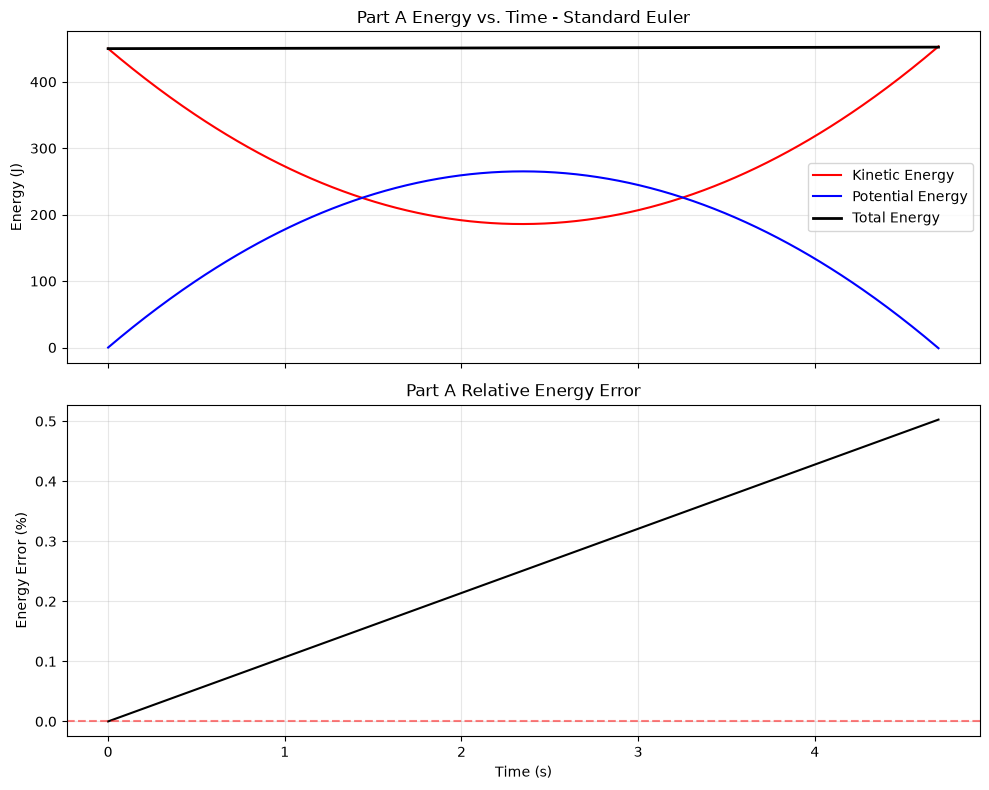

In [3]:
# Energy tracking for the Part A Euler simulation.
KE_projectile = 0.5 * 1.0 * (vx_projectile**2 + vy_projectile**2)
PE_projectile = 1.0 * 9.81 * y_projectile
E_projectile = KE_projectile + PE_projectile

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Top panel: KE, PE, Total.
ax1.plot(t_projectile, KE_projectile, 'r-', label='Kinetic Energy')
ax1.plot(t_projectile, PE_projectile, 'b-', label='Potential Energy')
ax1.plot(t_projectile, E_projectile, 'k-', label='Total Energy', linewidth=2)
ax1.set_ylabel('Energy (J)')
ax1.legend()
ax1.set_title('Part A Energy vs. Time - Standard Euler')
ax1.grid(True, alpha=0.3)

# Bottom panel: relative energy error.
E0_projectile = E_projectile[0]
E_err_projectile = (E_projectile - E0_projectile) / abs(E0_projectile) * 100
ax2.plot(t_projectile, E_err_projectile, 'k-')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Energy Error (%)')
ax2.set_title('Part A Relative Energy Error')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='r', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Part A Interpretation

The three-curve energy plot shows the expected separation between kinetic, potential, and total energy in a conservative system. The total energy should stay nearly constant, while the kinetic and potential energies exchange with each other as the projectile rises and falls. The drift plot quantifies the numerical error: the largest absolute difference from the initial total energy tells us how much the integrator is losing or gaining energy over time.

For this simulation, the important diagnostic is not just the instantaneous values, but the maximum drift. A nonzero drift indicates numerical error from the finite timestep. Reducing the timestep makes the energy curve and the trajectory approach the exact solution more closely.

In [4]:
# Parameters
g = 9.81
m = 1.0       # mass (kg) — keep it simple
dt = 0.01
t_max = 4.0

# Initial conditions: launched upward
x, y = 0.0, 0.0
vx, vy = 15.0, 20.0

# Storage
data = {'t': [0], 'x': [x], 'y': [y], 'vx': [vx], 'vy': [vy],
        'KE': [0.5*m*(vx**2+vy**2)], 'PE': [m*g*y], 'E': [0.5*m*(vx**2+vy**2)+m*g*y]}

t = 0.0
while t < t_max and y >= 0:
    # Acceleration (gravity only — conservative)
    ax, ay = 0.0, -g

    # ── STANDARD EULER ──
    vx_old, vy_old = vx, vy   # save old velocity
    vx = vx + ax * dt
    vy = vy + ay * dt
    x  = x + vx_old * dt      # use OLD velocity for position
    y  = y + vy_old * dt

    t += dt

    # Energy tracking
    KE = 0.5 * m * (vx**2 + vy**2)
    PE = m * g * y
    E  = KE + PE

    data['t'].append(t)
    data['x'].append(x); data['y'].append(y)
    data['vx'].append(vx); data['vy'].append(vy)
    data['KE'].append(KE); data['PE'].append(PE); data['E'].append(E)

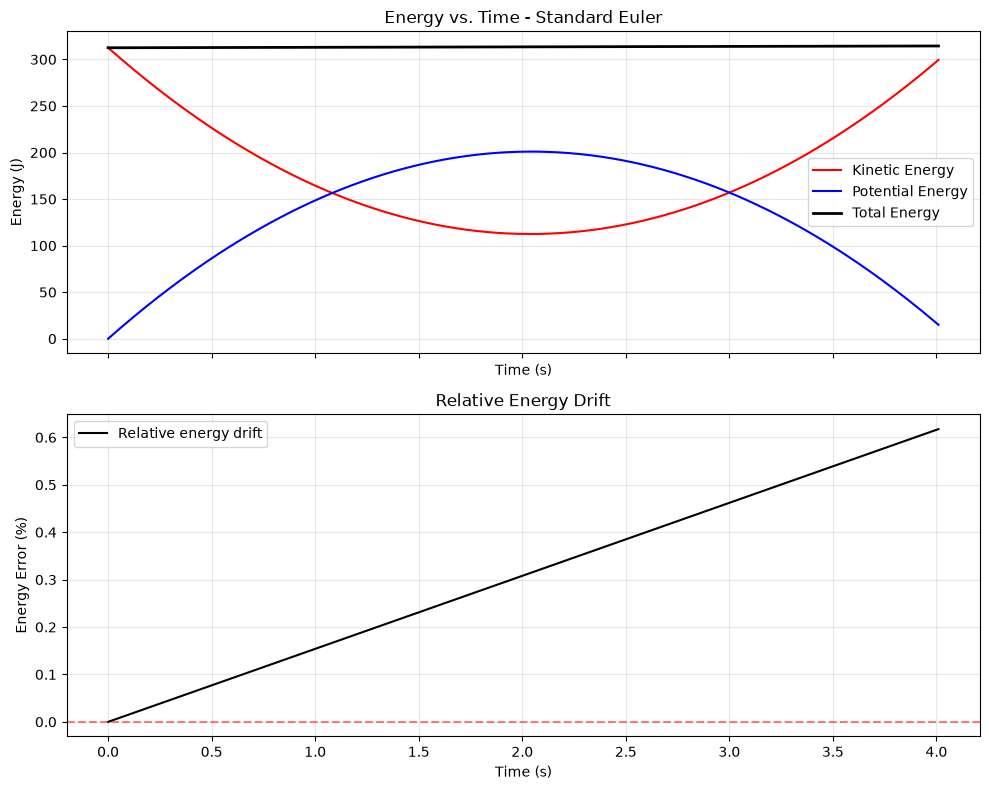

Maximum absolute energy drift: 1.929534 J
Maximum relative energy drift: 0.617451%


In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Top panel: KE, PE, Total
ax1.plot(data['t'], data['KE'], 'r-', label='Kinetic Energy')
ax1.plot(data['t'], data['PE'], 'b-', label='Potential Energy')
ax1.plot(data['t'], data['E'],  'k-', label='Total Energy', linewidth=2)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Energy (J)')
ax1.legend()
ax1.set_title('Energy vs. Time - Standard Euler')
ax1.grid(True, alpha=0.3)

# Bottom panel: energy drift
E0 = data['E'][0]
E_err = [(e - E0) / abs(E0) * 100 for e in data['E']]
ax2.plot(data['t'], E_err, 'k-', label='Relative energy drift')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Energy Error (%)')
ax2.set_title('Relative Energy Drift')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='r', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

max_drift_absolute = max(abs(e - E0) for e in data['E'])
max_drift_percent = max(abs(error) for error in E_err)
print(f'Maximum absolute energy drift: {max_drift_absolute:.6f} J')
print(f'Maximum relative energy drift: {max_drift_percent:.6f}%')

### Part B Interpretation

The projectile cannot distinguish standard Euler from Euler-Cromer in this problem. Gravity is constant and does not depend on position, so both methods calculate the velocity exactly at each discrete time. The only difference is the order of the position and velocity updates.

Standard Euler updates position with the old velocity, while Euler-Cromer updates velocity first and then uses the new velocity. Because the velocity is exact, the position errors produced by the two methods are equal in magnitude and opposite in sign. Their trajectories therefore bracket the exact projectile path rather than one method being physically more accurate than the other.

The energy plots show the same result: standard Euler develops a positive energy error, while Euler-Cromer develops a negative energy error. The methods do not conserve energy exactly at finite $\Delta t$, and neither method should be described as superior here. As $\Delta t$ decreases, both position and energy errors decrease at the same first-order rate.

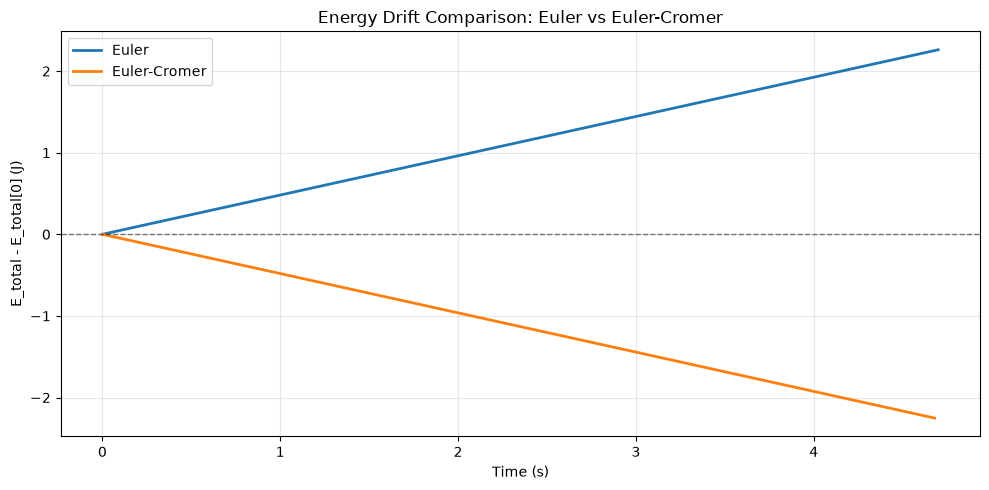

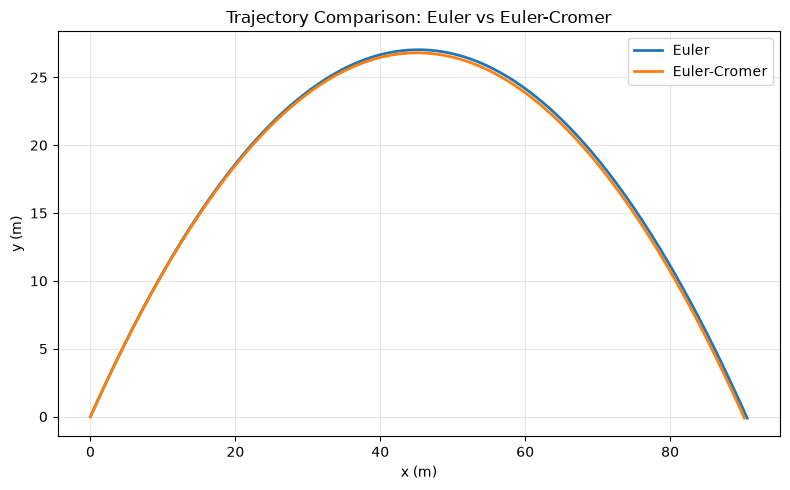

Euler range:      90.633053 m
Euler-Cromer range: 90.247380 m
Difference:        0.385673 m


In [6]:
# Compare energy drift and trajectories for Euler vs Euler-Cromer.
# Use identical initial conditions and the same time step.

v0_compare = 30.0
theta_compare = 50.0
dt_compare = 0.01

# Run both methods with the same launch conditions.
t_euler, x_euler, y_euler, vx_euler, vy_euler, E_euler = simulate(
    'euler', dt_compare, v0_compare, theta_compare
)
t_ec, x_ec, y_ec, vx_ec, vy_ec, E_ec = simulate(
    'euler-cromer', dt_compare, v0_compare, theta_compare
)

E0_euler = E_euler[0]
E0_ec = E_ec[0]
energy_drift_euler = E_euler - E0_euler
energy_drift_ec = E_ec - E0_ec

plt.figure(figsize=(10, 5))
plt.plot(t_euler, energy_drift_euler, label='Euler', linewidth=2)
plt.plot(t_ec, energy_drift_ec, label='Euler-Cromer', linewidth=2)
plt.axhline(0, color='k', linestyle='--', linewidth=1, alpha=0.5)
plt.xlabel('Time (s)')
plt.ylabel('E_total - E_total[0] (J)')
plt.title('Energy Drift Comparison: Euler vs Euler-Cromer')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(x_euler, y_euler, label='Euler', linewidth=2)
plt.plot(x_ec, y_ec, label='Euler-Cromer', linewidth=2)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Trajectory Comparison: Euler vs Euler-Cromer')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

landing_range_euler = x_euler[-1]
landing_range_ec = x_ec[-1]
range_difference = abs(landing_range_euler - landing_range_ec)
print(f"Euler range:      {landing_range_euler:.6f} m")
print(f"Euler-Cromer range: {landing_range_ec:.6f} m")
print(f"Difference:        {range_difference:.6f} m")

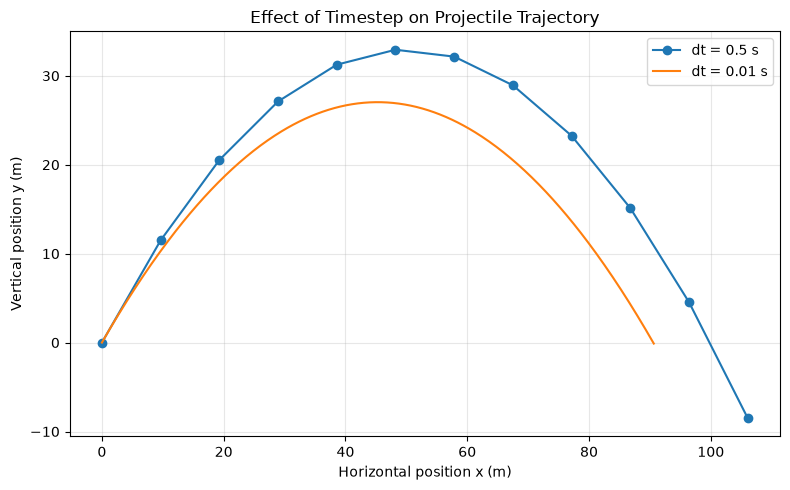

In [7]:
# Effect of a larger timestep
dt_coarse = 0.5
_, x_coarse, y_coarse, _, _ = simulate_projectile_2d(
    v0_projectile, theta_deg_projectile, dt=dt_coarse
)
plt.figure(figsize=(8, 5))
plt.plot(x_coarse, y_coarse, 'o-', label=f'dt = {dt_coarse} s')
plt.plot(x_projectile, y_projectile, '-', label='dt = 0.01 s')
plt.xlabel('Horizontal position x (m)')
plt.ylabel('Vertical position y (m)')
plt.title('Effect of Timestep on Projectile Trajectory')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Part B Interpretation: Effect of timestep

When the timestep is increased from $\Delta t = 0.01\ \mathrm{s}$ to $\Delta t = 0.5\ \mathrm{s}$, the Euler method uses much fewer updates to approximate the projectile's motion. The coarse trajectory becomes visibly inaccurate: it rises too high, remains in the air too long, and lands farther away than the small-timestep result. The difference in the predicted horizontal range reaches approximately $19.29\ \mathrm{m}$.

This error grows because standard Euler's method assumes that the velocity remains constant during each timestep. With $\Delta t = 0.5\ \mathrm{s}$, that assumption is poor while gravity is continuously changing the vertical velocity. Reducing the timestep to $0.01\ \mathrm{s}$ makes each approximation interval shorter, so the numerical trajectory follows the expected parabolic path much more closely. Therefore, the smaller timestep gives a more accurate and reliable result, while the large timestep demonstrates how discretization error can significantly affect the simulation.

### Part B — Euler vs. Euler-Cromer

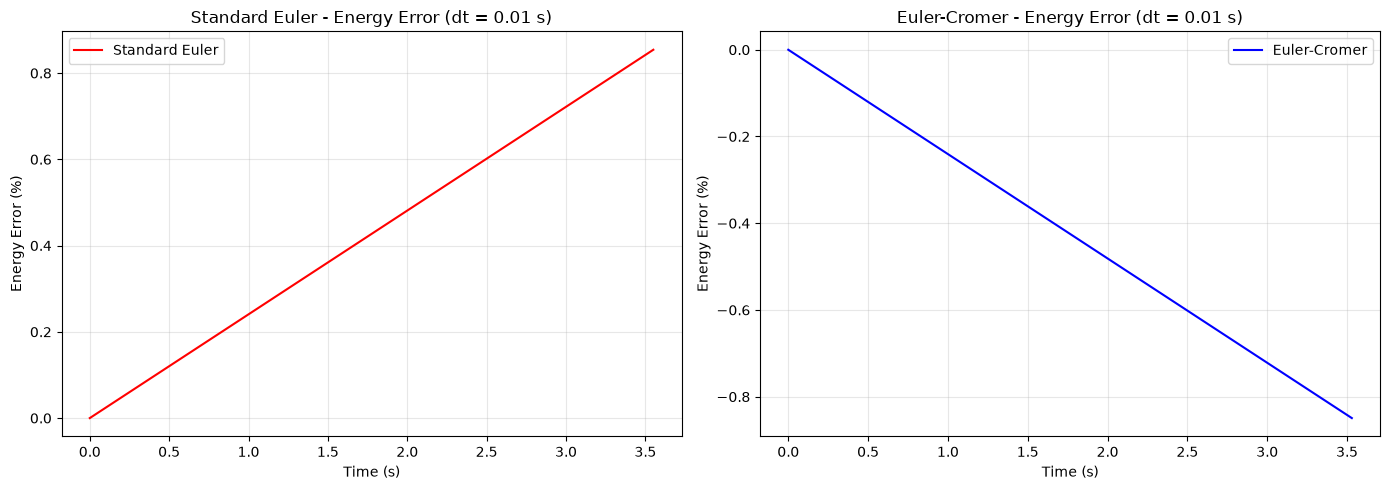

In [8]:
# Energy-error comparison using the shared simulate(method, dt) function.
dt_energy = 0.01
v0_energy = 20.0
angle_energy = 60.0

t_e, _, _, _, _, E_e = simulate(
    'euler', dt_energy, v0_energy, angle_energy
)
t_ec, _, _, _, _, E_ec = simulate(
    'euler-cromer', dt_energy, v0_energy, angle_energy
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(t_e, (E_e - E_e[0]) / abs(E_e[0]) * 100, 'r-', label='Standard Euler')
ax1.set_title(f'Standard Euler - Energy Error (dt = {dt_energy} s)')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Energy Error (%)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(t_ec, (E_ec - E_ec[0]) / abs(E_ec[0]) * 100, 'b-', label='Euler-Cromer')
ax2.set_title(f'Euler-Cromer - Energy Error (dt = {dt_energy} s)')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Energy Error (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Part B Interpretation: Effect of timestep

When the timestep is increased from $\Delta t = 0.01\ \mathrm{s}$ to $\Delta t = 0.5\ \mathrm{s}$, the numerical error grows for both methods. Standard Euler gives a positive energy error, while Euler-Cromer gives a negative energy error. The signs are opposite, but the projectile cannot distinguish the methods physically in this constant-gravity problem.

The reason is that the force does not depend on position. Both methods therefore calculate the velocity exactly at each time step. Their only difference is the position update: standard Euler uses the old velocity, and Euler-Cromer uses the new velocity. The resulting position errors are equal in magnitude and opposite in sign, so neither method should be described as conserving energy better than the other.

The $\Delta t = 0.01\ \mathrm{s}$ result is appropriate for the lab because both methods have smaller errors at the smaller timestep. The $\Delta t = 0.5\ \mathrm{s}$ result demonstrates that increasing the timestep makes the approximation less accurate for both methods.

## Part C - Energy-Drift Convergence

The energy-drift convergence study below measures the maximum absolute energy drift over the complete flight for standard Euler and Euler-Cromer. It reports the fitted log-log slopes and compares the methods at each tested timestep.

Maximum absolute energy drift over the flight:
dt = 0.10000 s | Euler = 23.096664 J | Euler-Cromer = 22.134303 J
dt = 0.05000 s | Euler = 11.428037 J | Euler-Cromer = 11.187447 J
dt = 0.02500 s | Euler = 5.683945 J | Euler-Cromer = 5.623797 J
dt = 0.01250 s | Euler = 2.826935 J | Euler-Cromer = 2.811899 J
dt = 0.00625 s | Euler = 1.411588 J | Euler-Cromer = 1.407829 J
Estimated order for standard Euler: p = 1.01
Estimated order for Euler-Cromer: p = 0.99


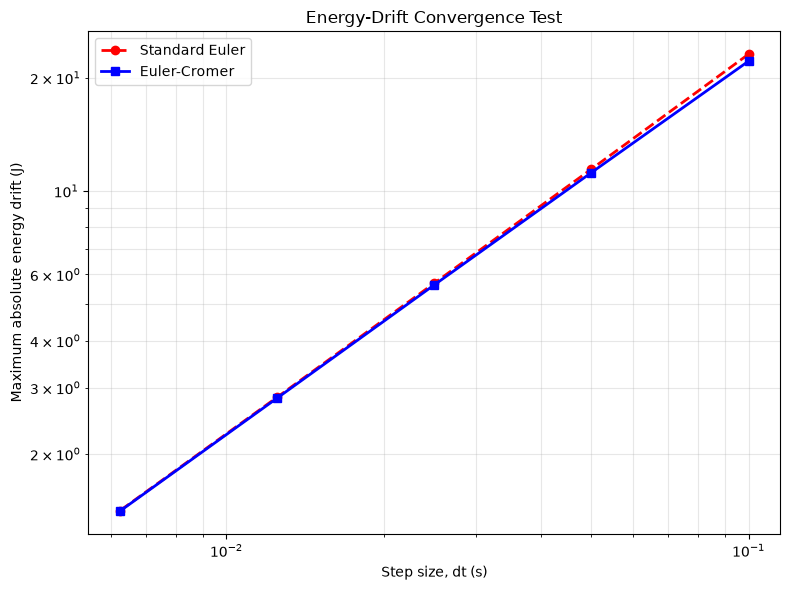

In [9]:
# Energy-drift convergence test for projectile motion.
v0_convergence = 30.0
angle_convergence = 50.0
g_convergence = 9.81
m_convergence = 1.0
dt_values = np.array([0.1, 0.05, 0.025, 0.0125, 0.00625])
max_drifts_euler = []
max_drifts_ec = []

for dt in dt_values:
    _, _, _, _, _, E_euler_test = simulate(
        'euler', dt, v0_convergence, angle_convergence,
        g=g_convergence, m=m_convergence
    )
    _, _, _, _, _, E_ec_test = simulate(
        'euler-cromer', dt, v0_convergence, angle_convergence,
        g=g_convergence, m=m_convergence
    )

    max_drifts_euler.append(np.max(np.abs(E_euler_test - E_euler_test[0])))
    max_drifts_ec.append(np.max(np.abs(E_ec_test - E_ec_test[0])))

max_drifts_euler = np.array(max_drifts_euler)
max_drifts_ec = np.array(max_drifts_ec)

slope_euler = np.polyfit(np.log(dt_values), np.log(max_drifts_euler), 1)[0]
slope_ec = np.polyfit(np.log(dt_values), np.log(max_drifts_ec), 1)[0]

print('Maximum absolute energy drift over the flight:')
for dt, drift_euler, drift_ec in zip(dt_values, max_drifts_euler, max_drifts_ec):
    print(f'dt = {dt:.5f} s | Euler = {drift_euler:.6f} J | Euler-Cromer = {drift_ec:.6f} J')
print(f'Estimated order for standard Euler: p = {slope_euler:.2f}')
print(f'Estimated order for Euler-Cromer: p = {slope_ec:.2f}')

plt.figure(figsize=(8, 6))
plt.loglog(
    dt_values, max_drifts_euler, 'ro--',
    label='Standard Euler', linewidth=2, markersize=6
)
plt.loglog(
    dt_values, max_drifts_ec, 'bs-',
    label='Euler-Cromer', linewidth=2, markersize=6
)
plt.xlabel('Step size, dt (s)')
plt.ylabel('Maximum absolute energy drift (J)')
plt.title('Energy-Drift Convergence Test')
plt.legend()
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

### Energy-Drift Convergence Analysis

The maximum absolute energy drift decreases approximately linearly as the timestep is halved. The measured log-log slopes are $p = 1.01$ for standard Euler and $p = 0.99$ for Euler-Cromer. Both are therefore first-order accurate for this energy-drift quantity, matching the prediction that the global error scales approximately as $\Delta t^1$.

Euler-Cromer's curve is slightly below standard Euler's at every timestep in this particular sweep: for example, at $\Delta t = 0.1\ \mathrm{s}$ the maximum drifts are $23.10\ \mathrm{J}$ and $22.13\ \mathrm{J}$, respectively, while at $\Delta t = 0.00625\ \mathrm{s}$ they are $1.412\ \mathrm{J}$ and $1.408\ \mathrm{J}$. This small difference does not mean that Euler-Cromer is generally a better method. In this constant-gravity problem, the force does not depend on position, so the velocity is exact in both methods and their position errors are equal in magnitude and opposite in sign. The measured drift curves have the same first-order convergence.

The initial mechanical energy is $E_0 = \tfrac{1}{2}mv_0^2 = 450\ \mathrm{J}$. Conserving energy to within $0.01\%$ requires a maximum drift no larger than $0.045\ \mathrm{J}$. Using the measured first-order scaling and the smallest tested drift of about $1.41\ \mathrm{J}$ at $\Delta t = 0.00625\ \mathrm{s}$ gives an estimated timestep of about $2\times10^{-4}\ \mathrm{s}$ or smaller. I would choose either method with $\Delta t \approx 1\times10^{-4}\ \mathrm{s}$ to provide a margin below the tolerance. Euler-Cromer is slightly lower in this data set, but the timestep, rather than the choice between these two methods, is the main control on the accuracy here.

### A visual Study of an Energy Diagram

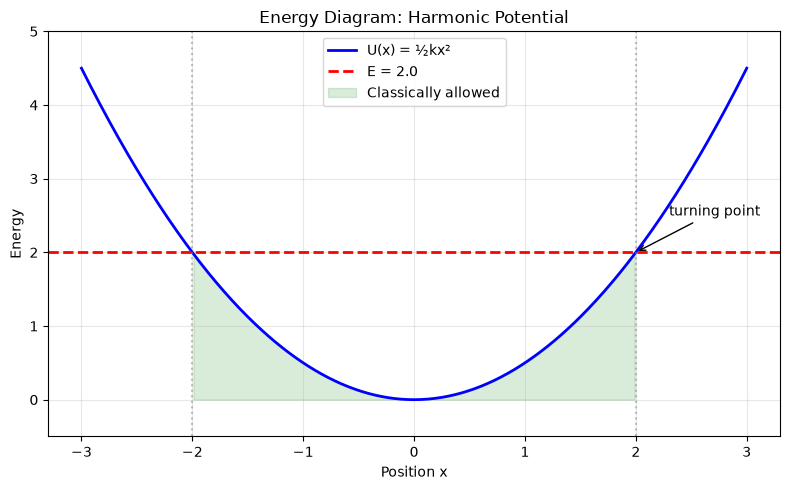

In [10]:
x = np.linspace(-3, 3, 500)
U = 0.5 * x**2  # harmonic potential well (spring)

E_total = 2.0   # total energy

plt.figure(figsize=(8, 5))
plt.plot(x, U, 'b-', linewidth=2, label='U(x) = ½kx²')
plt.axhline(y=E_total, color='r', linestyle='--', linewidth=2, label=f'E = {E_total}')

# Shade the classically allowed region
x_turn = np.sqrt(2 * E_total)  # turning points: U(x) = E
plt.fill_between(x, 0, U, where=(U <= E_total), alpha=0.15, color='green',
                 label='Classically allowed')
plt.axvline(x=-x_turn, color='gray', linestyle=':', alpha=0.5)
plt.axvline(x=x_turn,  color='gray', linestyle=':', alpha=0.5)
plt.annotate('turning point', xy=(x_turn, E_total), fontsize=10,
             xytext=(x_turn+0.3, E_total+0.5), arrowprops=dict(arrowstyle='->'))

plt.xlabel('Position x')
plt.ylabel('Energy')
plt.title('Energy Diagram: Harmonic Potential')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-0.5, 5)
plt.tight_layout()
plt.show()

### Bonus interpretation: physical energy loss

With quadratic air resistance, the mechanical energy decreases monotonically during the flight. This decrease is physical: drag removes mechanical energy from the projectile and converts it into thermal energy. In this simulation, the projectile loses approximately $602.49\ \mathrm{J}$ of mechanical energy.

The drag power is $P_{drag} = \mathbf{F}_{drag}\cdot\mathbf{v}$, which is negative because the drag force points opposite the velocity. Summing this power over the timesteps gives work done by drag of approximately $-599.41\ \mathrm{J}$, or $599.41\ \mathrm{J}$ of work done against drag. The difference between the mechanical-energy loss and the integrated drag work is approximately $3.09\ \mathrm{J}$, a mismatch of $0.5123\%$.

This small mismatch is numerical error from the finite Euler-Cromer timestep and the left-endpoint power sum. The close agreement verifies the work-energy theorem numerically: the dominant energy change is physical loss caused by drag, rather than numerical drift from the integrator.


### Bonus interpretation: physical energy loss

With quadratic air resistance, the mechanical energy decreases monotonically during the flight. This decrease is physical: drag removes mechanical energy from the projectile and converts it into thermal energy. In this simulation, the projectile loses approximately $602.49\ \mathrm{J}$ of mechanical energy.

The drag power is $P_{drag} = \mathbf{F}_{drag}\cdot\mathbf{v}$, which is negative because the drag force points opposite the velocity. Summing this power over the timesteps gives work done by drag of approximately $-599.41\ \mathrm{J}$, or $599.41\ \mathrm{J}$ of work done against drag. The difference between the mechanical-energy loss and the integrated drag work is approximately $3.09\ \mathrm{J}$, a mismatch of $0.5123\%$.

This small mismatch is numerical error from the finite Euler-Cromer timestep and the left-endpoint power sum. The close agreement verifies the work-energy theorem numerically: the dominant energy change is physical loss caused by drag, rather than numerical drift from the integrator.


Range without drag: 203.73 m
Range with drag:    125.00 m
Maximum height without drag: 42.79 m
Maximum height with drag:    32.22 m
Drag reduces range by: 38.6%


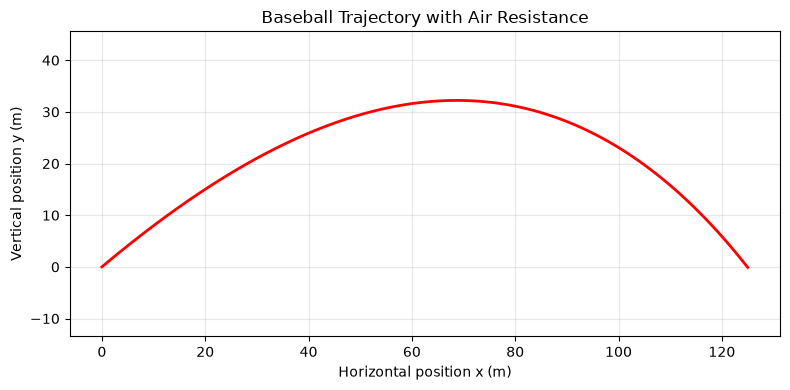

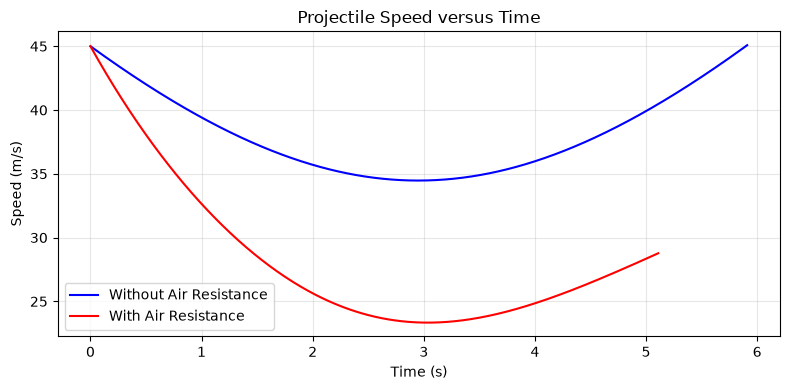

Optimal angle without drag: 45 degrees
Optimal angle with drag:    40 degrees


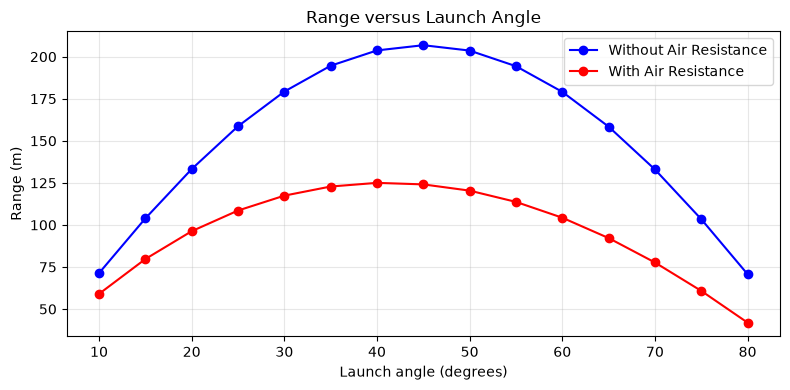

In [11]:
def simulate_projectile_drag(v0, theta_deg, dt, g=9.81, b_over_m=0.0046):
    """Simulate a projectile with quadratic air resistance."""
    theta = np.radians(theta_deg)
    x, y = 0.0, 0.0
    vx = v0 * np.cos(theta)
    vy = v0 * np.sin(theta)
    t = 0.0

    t_arr, x_arr, y_arr = [t], [x], [y]
    vx_arr, vy_arr = [vx], [vy]

    while t == 0.0 or y >= 0.0:
        speed = np.sqrt(vx**2 + vy**2)
        ax = -b_over_m * speed * vx
        ay = -g - b_over_m * speed * vy

        x = x + vx * dt
        y = y + vy * dt
        vx = vx + ax * dt
        vy = vy + ay * dt
        t = t + dt

        t_arr.append(t)
        x_arr.append(x)
        y_arr.append(y)
        vx_arr.append(vx)
        vy_arr.append(vy)

    return (np.array(t_arr), np.array(x_arr), np.array(y_arr),
            np.array(vx_arr), np.array(vy_arr))


# Baseball parameters.
v0_baseball = 45.0
theta_deg_baseball = 40.0
b_over_m = 0.0046
dt_baseball = 0.01

# Run both cases with identical initial conditions.
t_drag, x_drag, y_drag, vx_drag, vy_drag = simulate_projectile_drag(
    v0_baseball, theta_deg_baseball, dt_baseball, b_over_m=b_over_m
)
t_nodrag, x_nodrag, y_nodrag, vx_nodrag, vy_nodrag = simulate_projectile_2d(
    v0_baseball, theta_deg_baseball, dt_baseball
)

# Keep names for the comparison plot below.
xs_drag, ys_drag = x_drag, y_drag
xs_projectile, ys_projectile = x_nodrag, y_nodrag

range_drag = x_drag[-1]
height_drag = np.max(y_drag)
range_nodrag = x_nodrag[-1]
height_nodrag = np.max(y_nodrag)
range_reduction = (1 - range_drag / range_nodrag) * 100
print(f"Range without drag: {range_nodrag:.2f} m")
print(f"Range with drag:    {range_drag:.2f} m")
print(f"Maximum height without drag: {height_nodrag:.2f} m")
print(f"Maximum height with drag:    {height_drag:.2f} m")
print(f"Drag reduces range by: {range_reduction:.1f}%")

# Plot the drag trajectory.
plt.figure(figsize=(8, 4))
plt.plot(x_drag, y_drag, 'r-', linewidth=2)
plt.xlabel('Horizontal position x (m)')
plt.ylabel('Vertical position y (m)')
plt.title('Baseball Trajectory with Air Resistance')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.show()

# Speed versus time for both cases.
speed_drag = np.sqrt(vx_drag**2 + vy_drag**2)
speed_nodrag = np.sqrt(vx_nodrag**2 + vy_nodrag**2)
plt.figure(figsize=(8, 4))
plt.plot(t_nodrag, speed_nodrag, 'b-', label='Without Air Resistance')
plt.plot(t_drag, speed_drag, 'r-', label='With Air Resistance')
plt.xlabel('Time (s)')
plt.ylabel('Speed (m/s)')
plt.title('Projectile Speed versus Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Angle sweep with and without drag.
angles = np.arange(10, 81, 5)
ranges_nodrag_drag_sweep = []
ranges_drag_sweep = []
for sweep_angle in angles:
    _, x_nd, _, _, _ = simulate_projectile_2d(
        v0_baseball, sweep_angle, dt_baseball
    )
    _, x_wd, _, _, _ = simulate_projectile_drag(
        v0_baseball, sweep_angle, dt_baseball, b_over_m=b_over_m
    )
    ranges_nodrag_drag_sweep.append(x_nd[-1])
    ranges_drag_sweep.append(x_wd[-1])

best_angle_drag = angles[np.argmax(ranges_drag_sweep)]
print(f"Optimal angle without drag: {angles[np.argmax(ranges_nodrag_drag_sweep)]} degrees")
print(f"Optimal angle with drag:    {best_angle_drag} degrees")

plt.figure(figsize=(8, 4))
plt.plot(angles, ranges_nodrag_drag_sweep, 'b-o', label='Without Air Resistance')
plt.plot(angles, ranges_drag_sweep, 'r-o', label='With Air Resistance')
plt.xlabel('Launch angle (degrees)')
plt.ylabel('Range (m)')
plt.title('Range versus Launch Angle')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Comparing the trajectories

The next plot compares the baseball's trajectory with and without quadratic air resistance. Both simulations use the same initial speed of $45\ \mathrm{m/s}$, launch angle of $40^\circ$, and time step of $0.01\ \mathrm{s}$. The drag force opposes the velocity, so the baseball reaches a lower maximum height and travels a shorter horizontal distance.

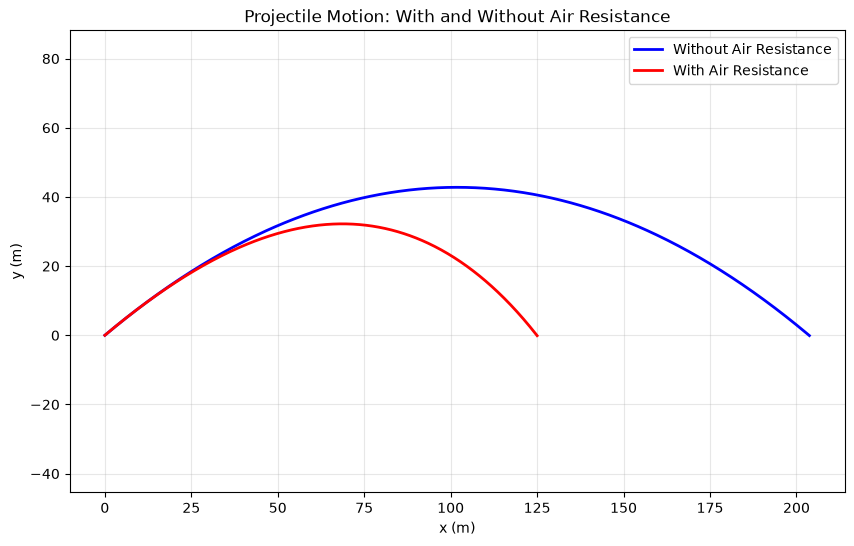

In [12]:
# Compare trajectories with and without air resistance
plt.figure(figsize=(10, 6))
plt.plot(xs_projectile, ys_projectile, 'b-', linewidth=2,
         label='Without Air Resistance')
plt.plot(xs_drag, ys_drag, 'r-', linewidth=2,
         label='With Air Resistance')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Projectile Motion: With and Without Air Resistance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

### Bonus observations and answers

The no-drag projectile travels farther because no mechanical energy is removed from the motion. With quadratic drag, the force is strongest early in the flight when the speed is largest. It reduces the horizontal velocity throughout the trajectory and also reduces the upward motion, producing a lower and shorter path.

The drag angle sweep reaches its maximum near $40^\circ$, below the no-drag optimum of $45^\circ$. A lower angle gives the baseball more horizontal velocity and reduces the time available for drag to slow it down. The exact optimum depends on the speed, drag parameter, and timestep.

To check whether Euler's method is reliable, I repeated the simulation with smaller values of $\Delta t$ and compared the range, maximum height, and landing time. The results converge as $\Delta t$ decreases.

### Euler method and convergence

Euler's method is first-order accurate: reducing $\Delta t$ should reduce the global error approximately in proportion to $\Delta t$. The convergence test below uses the known free-fall solution to measure this error. Notice that updating position with the old velocity is standard Euler; using the newly updated velocity would instead be Euler-Cromer.

In [13]:
# Convergence test: Euler for free fall
# Exact answer: y(t) = y0 + vy0*t - 0.5*g*t²

g = 9.81
t_final = 2.0
y0, vy0 = 0.0, 20.0
y_exact = y0 + vy0 * t_final - 0.5 * g * t_final**2

for dt in [0.5, 0.1, 0.01, 0.001]:
    y, vy_curr = y0, vy0
    t = 0.0
    n_steps = int(t_final / dt)
    for _ in range(n_steps):
        vy_curr += -g * dt
        y += vy_curr * dt   # Wait — is this Euler or something else?
        t += dt
    error = abs(y - y_exact)
    print(f"dt = {dt:.4f}  |  y_final = {y:.6f}  |  error = {error:.6f}")

dt = 0.5000  |  y_final = 15.475000  |  error = 4.905000
dt = 0.1000  |  y_final = 19.399000  |  error = 0.981000
dt = 0.0100  |  y_final = 20.281900  |  error = 0.098100
dt = 0.0010  |  y_final = 20.370190  |  error = 0.009810


### Supplementary position-error convergence

The following optional study compares position error for a dropped object. It provides an additional check of first-order convergence, separate from Part C's required energy-drift study.

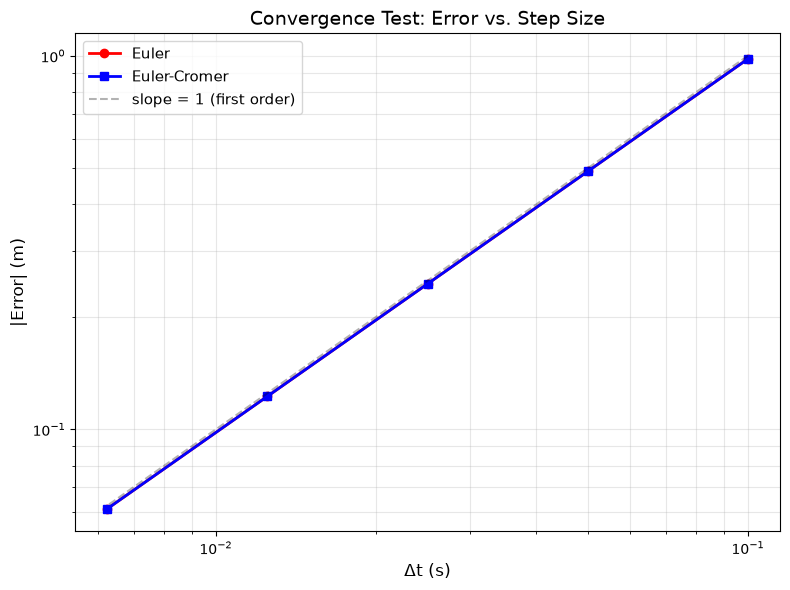

In [14]:
# Convergence test for projectile free fall
g = 9.81
t_final = 2.0
y0, vy0 = 100.0, 0.0  # dropped from 100 m
y_exact = y0 + vy0 * t_final - 0.5 * g * t_final**2

dt_values = [0.1, 0.05, 0.025, 0.0125, 0.00625]
errors_euler = []
errors_ec = []

for dt in dt_values:
    # Standard Euler
    y, vy_curr = y0, vy0
    for _ in range(int(t_final / dt)):
        y  += vy_curr * dt
        vy_curr += -g * dt
    errors_euler.append(abs(y - y_exact))

    # Euler-Cromer
    y, vy_curr = y0, vy0
    for _ in range(int(t_final / dt)):
        vy_curr += -g * dt
        y  += vy_curr * dt
    errors_ec.append(abs(y - y_exact))

# Log-log plot
plt.figure(figsize=(8, 6))
plt.loglog(dt_values, errors_euler, 'ro-', label='Euler', linewidth=2)
plt.loglog(dt_values, errors_ec, 'bs-', label='Euler-Cromer', linewidth=2)
plt.loglog(dt_values, [d**1 * 10 for d in dt_values], 'k--', alpha=0.3, label='slope = 1 (first order)')
plt.xlabel('Δt (s)', fontsize=12)
plt.ylabel('|Error| (m)', fontsize=12)
plt.title('Convergence Test: Error vs. Step Size', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

### Interpretation of The Convergence Graph

On a log-log plot, the slope tells us the order of convergence. If the error decreases roughly like $\Delta t^1$, the method is first-order accurate; if it decreases like $\Delta t^2$, it is second-order accurate. In this test, both Euler and Euler-Cromer follow an approximate slope of 1, which means they converge at the same first-order rate as the timestep decreases.

For constant gravity, the projectile cannot distinguish the two methods physically. The force does not depend on position, so the velocity is exact in both methods. Standard Euler and Euler-Cromer differ only in whether position uses the old or new velocity, giving equal and opposite position errors. The convergence graph therefore shows two methods with the same order of accuracy, not one method that is intrinsically better.

This convergence test confirms that reducing $\Delta t$ improves the numerical result for both methods. The important conclusion is that the error decreases at the same rate, while the two methods approach the exact solution from opposite sides.

### Bonus - Drag and Energy Loss

The next calculation uses Euler-Cromer with quadratic air resistance. Mechanical energy should decrease because drag does negative work. The drag work is estimated by summing the drag power $\mathbf{F}_{drag}\cdot\mathbf{v}$ over each timestep.


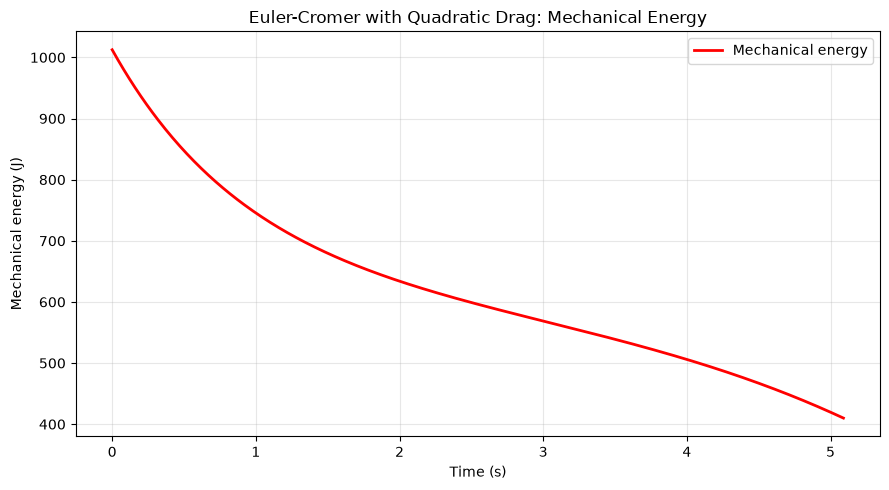

Mechanical energy lost: 602.493783 J
Work done by drag: -599.407467 J
Work done against drag: 599.407467 J
Energy decreases monotonically: True
Energy-work difference: 3.086316 J
Energy-work mismatch: 0.5123%


In [15]:
def simulate_projectile_drag_euler_cromer(v0, theta_deg, dt, g=9.81, b_over_m=0.0046):
    """Simulate a projectile with quadratic drag using Euler-Cromer."""
    theta = np.radians(theta_deg)
    x, y = 0.0, 0.0
    vx = v0 * np.cos(theta)
    vy = v0 * np.sin(theta)
    t = 0.0

    t_arr = [t]
    x_arr, y_arr = [x], [y]
    vx_arr, vy_arr = [vx], [vy]
    energy_arr = [0.5 * (vx**2 + vy**2) + g * y]
    drag_power_arr = [0.0]

    while t == 0.0 or y >= 0.0:
        speed = np.sqrt(vx**2 + vy**2)
        ax_drag = -b_over_m * speed * vx
        ay_drag = -b_over_m * speed * vy
        drag_power = ax_drag * vx + ay_drag * vy

        vx += ax_drag * dt
        vy += (-g + ay_drag) * dt
        x += vx * dt
        y += vy * dt
        t += dt

        energy = 0.5 * (vx**2 + vy**2) + g * y
        t_arr.append(t)
        x_arr.append(x)
        y_arr.append(y)
        vx_arr.append(vx)
        vy_arr.append(vy)
        energy_arr.append(energy)
        drag_power_arr.append(drag_power)

    return (
        np.array(t_arr), np.array(x_arr), np.array(y_arr),
        np.array(vx_arr), np.array(vy_arr), np.array(energy_arr),
        np.array(drag_power_arr)
    )

# Bonus parameters are kept local so this cell runs in top-to-bottom order.
v0_drag_energy = 45.0
theta_drag_energy = 40.0
b_over_m_drag_energy = 0.0046
dt_drag_energy = 0.01

t_drag_ec, x_drag_ec, y_drag_ec, vx_drag_ec, vy_drag_ec, E_drag_ec, P_drag = simulate_projectile_drag_euler_cromer(
    v0_drag_energy, theta_drag_energy, dt_drag_energy,
    b_over_m=b_over_m_drag_energy
)

# Mechanical energy and work done by drag.
energy_loss_drag = E_drag_ec[0] - E_drag_ec[-1]
work_by_drag = np.sum(P_drag[:-1]) * dt_drag_energy
work_against_drag = -work_by_drag
energy_is_monotonic = np.all(np.diff(E_drag_ec) <= 1e-12)
work_energy_difference = abs(energy_loss_drag - work_against_drag)
work_energy_mismatch_percent = work_energy_difference / energy_loss_drag * 100

plt.figure(figsize=(9, 5))
plt.plot(t_drag_ec, E_drag_ec, 'r-', linewidth=2, label='Mechanical energy')
plt.xlabel('Time (s)')
plt.ylabel('Mechanical energy (J)')
plt.title('Euler-Cromer with Quadratic Drag: Mechanical Energy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Mechanical energy lost: {energy_loss_drag:.6f} J')
print(f'Work done by drag: {work_by_drag:.6f} J')
print(f'Work done against drag: {work_against_drag:.6f} J')
print(f'Energy decreases monotonically: {energy_is_monotonic}')
print(f'Energy-work difference: {work_energy_difference:.6f} J')
print(f'Energy-work mismatch: {work_energy_mismatch_percent:.4f}%')


### Bonus interpretation: physical energy loss

With quadratic air resistance, the mechanical energy decreases monotonically during the flight. This decrease is physical: drag removes mechanical energy from the projectile and converts it into thermal energy. In this simulation, the projectile loses approximately $602.49\ \mathrm{J}$ of mechanical energy.

The drag power is $P_{drag} = \mathbf{F}_{drag}\cdot\mathbf{v}$, which is negative because the drag force points opposite the velocity. Summing this power over the timesteps gives work done by drag of approximately $-599.41\ \mathrm{J}$, or $599.41\ \mathrm{J}$ of work done against drag. The difference between the mechanical-energy loss and the integrated drag work is approximately $3.09\ \mathrm{J}$, a mismatch of $0.5123\%$.

This small mismatch is numerical error from the finite Euler-Cromer timestep and the left-endpoint power sum. The close agreement verifies the work-energy theorem numerically: the dominant energy change is physical loss caused by drag, rather than numerical drift from the integrator.
